# Asemic Code

## Installing vsketch & bezmerizing
**Note from Allison Parrish**: As of this writing (March 2025), the version of vsketch on PyPI does not install correctly on Python 3.13 or later. As a workaround, I've forked the repository on GitHub and updated the packaging information in my fork so that installation on 3.13 is possible. If you're using this notebook some time in the future, you should check to see if vsketch is compatible with your Python version, and use that instead of my fork!

In [1]:
# import sys
# !{sys.executable} -m pip install git+https://github.com/aparrish/vsketch

In [2]:
# import sys
# !{sys.executable} -m pip install --upgrade https://github.com/aparrish/bezmerizing/archive/main.zip

## Importing Packages

In [1]:
import vsketch
import bezmerizing
import math

## Importing Functions

In [2]:
from numpy.random import uniform, normal

## Specifying Paper Size

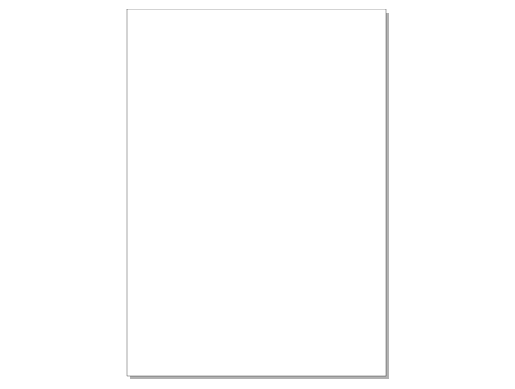

In [3]:
vsk = vsketch.Vsketch()
vsk.size("a4")
vsk.display()

## Basic Grid Layout

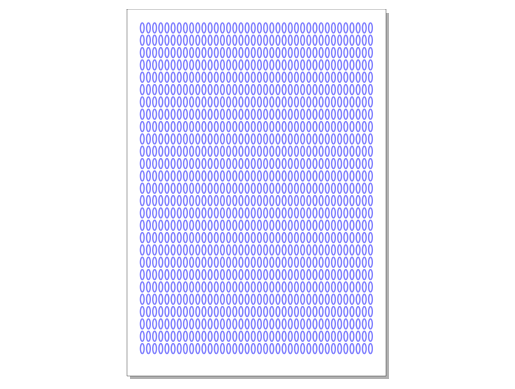

In [4]:
paper_width = 210
paper_height = 297
paper_padding = 10
character_width = 5
character_height = 10
character_padding = 2
max_character_num_per_line = math.floor((paper_width - paper_padding * 2) / character_width)
max_line_num_per_page = math.floor((paper_height - paper_padding * 2) / character_height)
layout_offset_x = paper_padding + character_width * 0.5
layout_offset_y = paper_padding + character_height * 0.5
vsk = vsketch.Vsketch()
vsk.size(str(paper_width)+"mm", str(paper_height)+"mm", center=False)
vsk.scale("1mm");

for c in range(max_character_num_per_line):
    for r in range(max_line_num_per_page):
        x = c * character_width + layout_offset_x
        y = r * character_height + layout_offset_y
        vsk.ellipse(x, y, character_width-character_padding, character_height - character_padding)
    
vsk.display()

## Adapative Layout

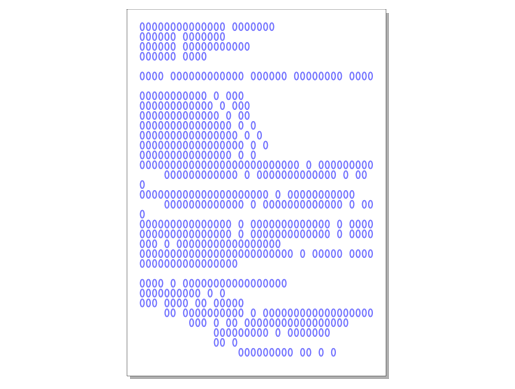

In [5]:
paper_width = 210
paper_height = 297
paper_padding = 10
character_width = 5
character_height = 8
character_padding = 2
max_character_num_per_line = math.floor((paper_width - paper_padding * 2) / character_width)
max_line_num_per_page = math.floor((paper_height - paper_padding * 2) / character_height)
layout_offset_x = paper_padding + character_width * 0.5
layout_offset_y = paper_padding + character_height * 0.5
vsk = vsketch.Vsketch()
vsk.size(str(paper_width)+"mm", str(paper_height)+"mm", center=False)
vsk.scale("1mm");

text = open("asemic-code.py")
line_index = 0
for line in text:
    if (line_index < max_line_num_per_page):
        for c in range(len(line)):
            if (line[c] != ' ' and line[c] != '\n' and c < max_character_num_per_line):
                x = c * character_width + layout_offset_x
                y = line_index * character_height + layout_offset_y
                vsk.ellipse(x, y, character_width-character_padding, character_height - character_padding)
    line_index += 1
    
vsk.display()

## Simple Asemic Glyph

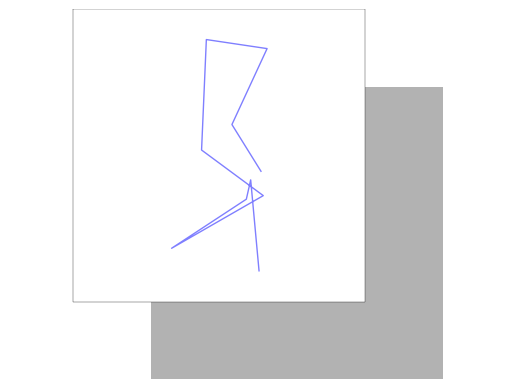

In [6]:
vsk = vsketch.Vsketch()
vsk.size("10mm", "10mm")
vsk.scale("1mm");

points = []
for i in range(10):
    points.append([uniform(-0.5, 0.5), uniform(-0.5, 0.5)])

with vsk.pushMatrix():
    vsk.scale(5, 10)
    vsk.polygon(points)

vsk.display()

## Applying Asemic Glyph to Layout

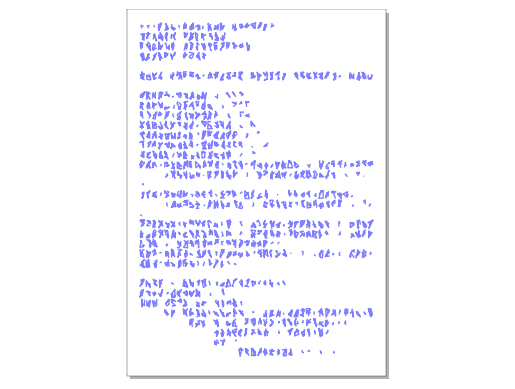

In [7]:
paper_width = 210
paper_height = 297
paper_padding = 10
character_width = 5
character_height = 8
character_padding = 1
max_character_num_per_line = math.floor((paper_width - paper_padding * 2) / character_width)
max_line_num_per_page = math.floor((paper_height - paper_padding * 2) / character_height)
layout_offset_x = paper_padding + character_width * 0.5
layout_offset_y = paper_padding + character_height * 0.5
vsk = vsketch.Vsketch()
vsk.size(str(paper_width)+"mm", str(paper_height)+"mm", center=False)
vsk.scale("1mm");

text = open("asemic-code.py")
line_index = 0
for line in text:
    if (line_index < max_line_num_per_page):
        for c in range(len(line)):
            character = line[c]
            if (character != ' ' and character != '\n' and c < max_character_num_per_line):
                x = c * character_width + layout_offset_x
                y = line_index * character_height + layout_offset_y
                w = character_width-character_padding
                h = character_height - character_padding
                points = []
                if (character.isalpha()):
                    glyph_complexity = 8
                elif (character.isdigit()):
                    glyph_complexity = 5
                else:
                    glyph_complexity = 3
                for i in range(glyph_complexity):
                    if (character.isupper() or character.isdigit()):
                        glyph_point =  [uniform(-0.5, 0.5), uniform(-0.5, 0.2)]
                    elif (character.islower()):
                        glyph_point =  [uniform(-0.5, 0.5), uniform(-0.5, 0.5)]
                    else:
                        glyph_point =  [uniform(-0.3, 0.3), uniform(-0.3, 0.3)]
                    points.append(glyph_point)
                with vsk.pushMatrix():
                    vsk.translate(x, y)
                    vsk.scale(w, h)
                    vsk.polygon(points)
    line_index += 1
    
vsk.display()

## Applying Simple Syntax Highlighting

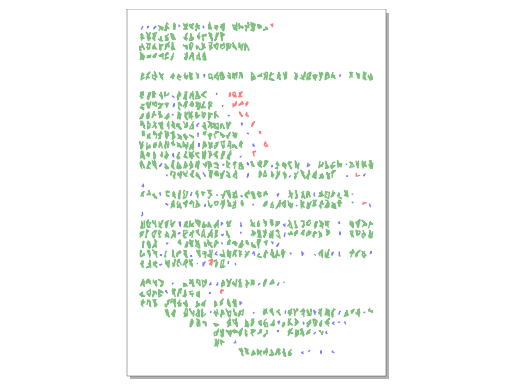

In [8]:
paper_width = 210
paper_height = 297
paper_padding = 10
character_width = 5
character_height = 8
character_padding = 1
max_character_num_per_line = math.floor((paper_width - paper_padding * 2) / character_width)
max_line_num_per_page = math.floor((paper_height - paper_padding * 2) / character_height)
layout_offset_x = paper_padding + character_width * 0.5
layout_offset_y = paper_padding + character_height * 0.5
vsk = vsketch.Vsketch()
vsk.size(str(paper_width)+"mm", str(paper_height)+"mm", center=False)
vsk.scale("1mm");

text = open("asemic-code.py")
line_index = 0
for line in text:
    if (line_index < max_line_num_per_page):
        for c in range(len(line)):
            character = line[c]
            if (character != ' ' and character != '\n' and c < max_character_num_per_line):
                x = c * character_width + layout_offset_x
                y = line_index * character_height + layout_offset_y
                w = character_width-character_padding
                h = character_height - character_padding
                points = []
                if (character.isalpha()):
                    glyph_complexity = 8
                    stroke_color = 1
                elif (character.isdigit()):
                    glyph_complexity = 5
                    stroke_color = 2
                else:
                    glyph_complexity = 3
                    stroke_color = 3
                for i in range(glyph_complexity):
                    if (character.isupper() or character.isdigit()):
                        glyph_point =  [uniform(-0.5, 0.5), uniform(-0.5, 0.2)]
                    elif (character.islower()):
                        glyph_point =  [uniform(-0.5, 0.5), uniform(-0.5, 0.5)]
                    else:
                        glyph_point =  [uniform(-0.3, 0.3), uniform(-0.3, 0.3)]
                    points.append(glyph_point)
                vsk.stroke(stroke_color)
                with vsk.pushMatrix():
                    vsk.translate(x, y)
                    vsk.scale(w, h)
                    vsk.polygon(points)
    line_index += 1
    
vsk.display()

## Curved Glyphs

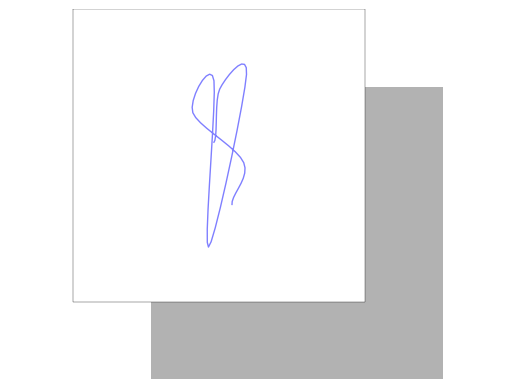

In [9]:
vsk = vsketch.Vsketch()
vsk.size("10mm", "10mm")
vsk.scale("1mm");

points = []
for i in range(10):
    points.append([normal(0, 0.2), normal(0, 0.2)])
    
curve_points = bezmerizing.Polyline(points).catmull_spline().to_polyline(10)

with vsk.pushMatrix():
    vsk.scale(5, 10)
    vsk.polygon(curve_points)

vsk.display()

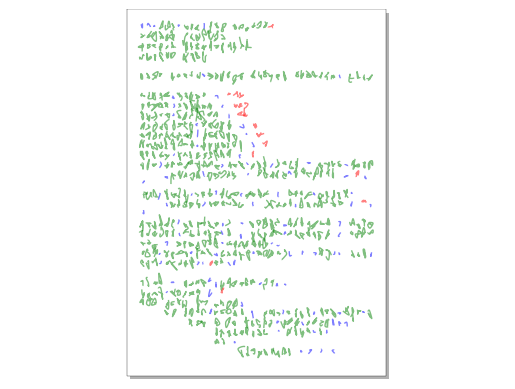

In [10]:
paper_width = 210
paper_height = 297
paper_padding = 10
character_width = 5
character_height = 8
character_padding = 1
curve_tightness = 8
max_character_num_per_line = math.floor((paper_width - paper_padding * 2) / character_width)
max_line_num_per_page = math.floor((paper_height - paper_padding * 2) / character_height)
layout_offset_x = paper_padding + character_width * 0.5
layout_offset_y = paper_padding + character_height * 0.5
vsk = vsketch.Vsketch()
vsk.size(str(paper_width)+"mm", str(paper_height)+"mm", center=False)
vsk.scale("1mm");

text = open("asemic-code.py")
line_index = 0
for line in text:
    if (line_index < max_line_num_per_page):
        for c in range(len(line)):
            character = line[c]
            if (character != ' ' and character != '\n' and c < max_character_num_per_line):
                x = c * character_width + layout_offset_x
                y = line_index * character_height + layout_offset_y
                w = character_width-character_padding
                h = character_height - character_padding
                points = []
                if (character.isalpha()):
                    glyph_complexity = 8
                    stroke_color = 1
                elif (character.isdigit()):
                    glyph_complexity = 7
                    stroke_color = 2
                else:
                    glyph_complexity = 5
                    stroke_color = 3
                for i in range(glyph_complexity):
                    if (character.isupper() or character.isdigit()):
                        glyph_point = [normal(0, 0.4), normal(-0.1, 0.2)]
                    elif (character.islower()):
                        glyph_point = [normal(0, 0.3), normal(0, 0.3)]
                    else:
                        glyph_point = [normal(0, 0.2), normal(0, 0.2)]
                    points.append(glyph_point)

                curve_points = bezmerizing.Polyline(points).catmull_spline().to_polyline(curve_tightness)
                
                vsk.stroke(stroke_color)
                with vsk.pushMatrix():
                    vsk.translate(x, y)
                    vsk.scale(w, h)
                    vsk.polygon(curve_points)
    line_index += 1
    
vsk.display()